In [28]:


# ===================== CORE =====================
import pandas as pd
import numpy as np
import glob
import os

# ===================== SKLEARN =====================
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, matthews_corrcoef
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# ===================== METAHEURISTICS (mealpy) =====================
from mealpy import FloatVar
from mealpy import ACOR, AO, GA, PSO

# ===================== WARNINGS =====================
import warnings
warnings.filterwarnings("ignore")

In [29]:
DATA_PATH = "C:/codes/btp_datasets/TestCloudIDS_Dataset"

all_files = glob.glob(os.path.join(DATA_PATH, "**/*.csv"), recursive=True)

df_list = []
for file in all_files:
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Total shape:", df.shape)
df.tail()


Total shape: (119933, 84)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
119928,192.168.136.128-192.168.136.129-1145-38626-6,192.168.136.129,38626,192.168.136.128,1145,6,23/01/2024 12:30:25 PM,47,0,2,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RS_Scanner
119929,192.168.136.128-192.168.136.129-21-46376-6,192.168.136.129,46376,192.168.136.128,21,6,23/01/2024 12:30:24 PM,2874,2,2,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RS_Scanner
119930,192.168.136.128-192.168.136.129-21-46376-6,192.168.136.128,21,192.168.136.129,46376,6,23/01/2024 12:30:24 PM,25428,2,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
119931,192.168.136.128-192.168.136.129-81-47188-6,192.168.136.129,47188,192.168.136.128,81,6,23/01/2024 12:30:24 PM,1266,2,2,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RS_Scanner
119932,192.168.136.128-192.168.136.129-443-38532-6,192.168.136.129,38532,192.168.136.128,443,6,23/01/2024 12:30:24 PM,857,2,2,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RS_Scanner


In [30]:

# ===================== BASIC CLEANING =====================

# Drop Timestamp if exists
if "Timestamp" in df.columns:
    df = df.drop(columns=["Timestamp"])

# Replace infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with missing labels
df = df.dropna(subset=["Label"])


# ===================== LABEL PROCESSING =====================

# Ensure clean mapping
'''df["Label"] = df["Label"].replace({"Benign": 0})
df["Label"] = df["Label"].apply(lambda x: 0 if x == 0 else 1)

# Ensure integer type
df["Label"] = df["Label"].astype(int)
print(df["Label"].value_counts())'''

'df["Label"] = df["Label"].replace({"Benign": 0})\ndf["Label"] = df["Label"].apply(lambda x: 0 if x == 0 else 1)\n\n# Ensure integer type\ndf["Label"] = df["Label"].astype(int)\nprint(df["Label"].value_counts())'

In [31]:
from sklearn.preprocessing import LabelEncoder

min_samples = 50
class_counts = df["Label"].value_counts()
valid_classes = class_counts[class_counts >= min_samples].index
df = df[df["Label"].isin(valid_classes)]

# Step 2: Encode AFTER filtering (labels will be 0,1,2,3... no gaps)
le = LabelEncoder()
df["Label"] = le.fit_transform(df["Label"])
print("Classes:", le.classes_)

Classes: ['Benign' 'DDoS_Ripper' 'GoldenEye' 'HOIC' 'Hulk' 'LOIC_HTTP' 'RS_Scanner'
 'RS_l7_HTTP' 'SYN_Flood' 'TorsHammer' 'Xerxes']


In [32]:


# ===================== SPLIT FEATURES =====================

X = df.drop(columns=["Label"])
y = df["Label"]


# ===================== RENAME FEATURES =====================

'''orig_feats = X.columns.tolist()
mapping = {orig_feats[i]: f"F{i+1}" for i in range(len(orig_feats))}
X = X.rename(columns=mapping)
'''
# ===================== REMOVE NON-NUMERIC COLUMNS =====================

cols_to_drop = []

X = X.select_dtypes(include=['number'])

print("Dropping non-numeric columns:", cols_to_drop)

X = X.drop(columns=cols_to_drop)

# ===================== TRAIN TEST SPLIT =====================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ===================== FIX LABEL TYPE =====================

y_train = y_train.astype(int)
y_test = y_test.astype(int)

# ===================== IMPUTATION =====================

imputer = SimpleImputer(strategy="mean")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Imputation Done")


# ===================== EXTRA (USEFUL FOR LATER) =====================

# Save feature names
feature_names = X_train.columns.tolist()

# Check class distribution
print("Label Distribution:\n", y.value_counts())


Dropping non-numeric columns: []
Train Shape: (95913, 79)
Test Shape: (23979, 79)
Imputation Done
Label Distribution:
 Label
7     28235
0     25999
8     20909
5     10867
1     10020
3      8883
2      7407
4      2024
9      2024
10     2024
6      1500
Name: count, dtype: int64


In [33]:
print("no of features:", X_train.shape[1])
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

no of features: 79


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(20))

              feature  importance
0            Src Port    0.073422
20       Flow IAT Max    0.058257
1            Dst Port    0.055784
37     Bwd Header Len    0.048525
3       Flow Duration    0.046438
68  Init Bwd Win Byts    0.045001
21       Flow IAT Min    0.039407
17        Flow Pkts/s    0.039090
18      Flow IAT Mean    0.038526
36     Fwd Header Len    0.037655
38         Fwd Pkts/s    0.036136
39         Bwd Pkts/s    0.025929
56   Bwd Seg Size Avg    0.021629
41        Pkt Len Max    0.019698
44        Pkt Len Var    0.019522
46       SYN Flag Cnt    0.019436
54       Pkt Size Avg    0.018455
14   Bwd Pkt Len Mean    0.017554
42       Pkt Len Mean    0.016989
49       ACK Flag Cnt    0.016406


In [35]:
top_k = 30
selected_features = feature_importance['feature'][:top_k].tolist()
X_train = X_train[selected_features]
X_test = X_test[selected_features]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (95913, 30)
X_test shape: (23979, 30)


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from efficient_kan import KAN
from sklearn.metrics import classification_report

In [38]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.long)

In [39]:
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=128, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [55]:
num_classes = len(np.unique(y_train))
num_features = X_train.shape[1]
print(num_features)
print(num_classes)

30
11


In [41]:

kan_model = KAN(
    layers_hidden=[num_features, 32, num_classes]
).to(device)

print(kan_model)

KAN(
  (layers): ModuleList(
    (0-1): 2 x KANLinear(
      (base_activation): SiLU()
    )
  )
)


In [42]:
# ===================== CLASS WEIGHTS FOR IMBALANCE =====================
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = torch.optim.AdamW(kan_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

In [51]:
epochs = 20
best_val_loss = float('inf')
patience_counter = 0
patience = 15
X_test_t  = X_test_t.to(device)
y_test_t  = y_test_t.to(device)


In [52]:
for epoch in range(epochs):
    kan_model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = kan_model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Track training accuracy
        preds = output.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc  = correct / total
    train_loss = total_loss / len(train_loader)

    # Validation
    kan_model.eval()
    with torch.no_grad():
        val_output = kan_model(X_test_t)
        val_loss   = criterion(val_output, y_test_t).item()
        val_preds  = val_output.argmax(dim=1)
        val_acc    = (val_preds == y_test_t).float().mean().item()

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(kan_model.state_dict(), "best_kan.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 01 | Train Loss: 0.3123 | Train Acc: 0.9620 | Val Loss: 0.3242 | Val Acc: 0.9568
Epoch 02 | Train Loss: 0.3123 | Train Acc: 0.9619 | Val Loss: 0.3242 | Val Acc: 0.9568
Epoch 03 | Train Loss: 0.3118 | Train Acc: 0.9619 | Val Loss: 0.3242 | Val Acc: 0.9568
Epoch 04 | Train Loss: 0.3119 | Train Acc: 0.9618 | Val Loss: 0.3242 | Val Acc: 0.9567
Epoch 05 | Train Loss: 0.3111 | Train Acc: 0.9619 | Val Loss: 0.3242 | Val Acc: 0.9568
Epoch 06 | Train Loss: 0.3111 | Train Acc: 0.9619 | Val Loss: 0.3242 | Val Acc: 0.9568
Epoch 07 | Train Loss: 0.3111 | Train Acc: 0.9619 | Val Loss: 0.3242 | Val Acc: 0.9568
Epoch 08 | Train Loss: 0.3119 | Train Acc: 0.9619 | Val Loss: 0.3242 | Val Acc: 0.9568
Epoch 09 | Train Loss: 0.3123 | Train Acc: 0.9619 | Val Loss: 0.3242 | Val Acc: 0.9568
Epoch 10 | Train Loss: 0.3125 | Train Acc: 0.9619 | Val Loss: 0.3242 | Val Acc: 0.9567
Epoch 11 | Train Loss: 0.3124 | Train Acc: 0.9619 | Val Loss: 0.3242 | Val Acc: 0.9567
Epoch 12 | Train Loss: 0.3122 | Train Acc: 

In [53]:
# ===================== EVALUATE KAN =====================
kan_model.load_state_dict(torch.load("best_kan.pt"))
kan_model.eval()

with torch.no_grad():
    y_pred_kan = kan_model(X_test_t).argmax(dim=1).cpu().numpy()

print("=== KAN Classification Report ===")
print(classification_report(y_test, y_pred_kan, target_names=le.classes_))

=== KAN Classification Report ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5200
 DDoS_Ripper       0.98      0.95      0.97      2004
   GoldenEye       1.00      1.00      1.00      1481
        HOIC       1.00      1.00      1.00      1777
        Hulk       0.26      0.31      0.29       405
   LOIC_HTTP       1.00      1.00      1.00      2173
  RS_Scanner       1.00      1.00      1.00       300
  RS_l7_HTTP       0.98      0.99      0.99      5647
   SYN_Flood       1.00      1.00      1.00      4182
  TorsHammer       0.26      0.23      0.24       405
      Xerxes       0.26      0.24      0.25       405

    accuracy                           0.96     23979
   macro avg       0.79      0.79      0.79     23979
weighted avg       0.96      0.96      0.96     23979



In [54]:
kan_params = sum(p.numel() for p in kan_model.parameters())
print("KAN Parameters:", kan_params)

KAN Parameters: 13120


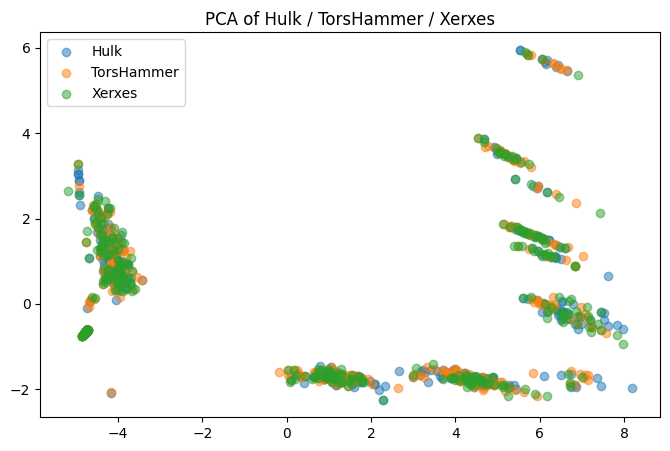

In [56]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Filter just the confusing classes
confused_labels = ['Hulk', 'TorsHammer', 'Xerxes']
confused_idx = [i for i, c in enumerate(le.classes_) if c in confused_labels]

mask = np.isin(y_test, confused_idx)
X_confused = X_test[mask]
y_confused = y_test.values[mask] if hasattr(y_test, 'values') else y_test[mask]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_confused)

plt.figure(figsize=(8,5))
for label in confused_idx:
    m = y_confused == label
    plt.scatter(X_pca[m,0], X_pca[m,1], label=le.classes_[label], alpha=0.5)
plt.legend()
plt.title("PCA of Hulk / TorsHammer / Xerxes")
plt.show()